In [40]:
import pandas as pd

file_path = r"D:\PROYEK MANDIRI\data\raw\DAYTON_hourly.csv"

df = pd.read_csv(file_path)

# Convert & sort
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

# Set index
df = df.set_index('Datetime')

df.head()

,DAYTON_MW
Datetime,
2004-10-01 01:00:00,1621.0
2004-10-01 02:00:00,1536.0
2004-10-01 03:00:00,1500.0
2004-10-01 04:00:00,1434.0
2004-10-01 05:00:00,1489.0


# 1. Preprocessing

In [41]:
print("Is index monotonic increasing? ", df.index.is_monotonic_increasing)
print("Is index unique? ", df.index.is_unique)
print("Inferred frequency: ", pd.infer_freq(df.index))

Is index monotonic increasing?  True
Is index unique?  False
Inferred frequency:  None


Expected value is:
- Is index monotonic increasing?  True
- Is index unique?  True
- Inferred frequency:  H

As you can see the previous output isnt what we expected
- Is index unique = False, there is duplicated timestamp
- Inferred frequency: None, there is duplicated and/or gap

In [42]:
duplicates = df.index[df.index.duplicated()]
print("Jumlah duplicate:", len(duplicates))

df[df.index.duplicated(keep=False)].head(10)

Jumlah duplicate: 4


,DAYTON_MW
Datetime,
2014-11-02 02:00:00,1623.0
2014-11-02 02:00:00,1634.0
2015-11-01 02:00:00,1324.0
2015-11-01 02:00:00,1292.0
2016-11-06 02:00:00,1334.0
2016-11-06 02:00:00,1364.0
2017-11-05 02:00:00,1449.0
2017-11-05 02:00:00,1331.0


In [43]:
df = df.groupby(df.index).mean()

print("Is index unique? ", df.index.is_unique)
print("Inferred frequency: ", pd.infer_freq(df.index))

Is index unique? 

 True
Inferred frequency:  None


No more duplicate, but there is missing timestamp (hourly gap).

In [44]:
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='h'
)

missing = full_range.difference(df.index)

print("Jumlah missing timestamp:", len(missing))
missing[:10]

Jumlah missing timestamp: 25


DatetimeIndex(['2004-10-31 02:00:00', '2005-04-03 03:00:00',
               '2005-10-30 02:00:00', '2006-04-02 03:00:00',
               '2006-10-29 02:00:00', '2007-03-11 03:00:00',
               '2007-11-04 02:00:00', '2008-03-09 03:00:00',
               '2008-11-02 02:00:00', '2009-03-08 03:00:00'],
              dtype='datetime64[ns]', freq=None)

In [45]:
df = df.asfreq('h')

print("Missing value setelah asfreq:")
print(df.isna().sum())

Missing value setelah asfreq:
DAYTON_MW    25
dtype: int64


In [46]:
df['DAYTON_MW'] = df['DAYTON_MW'].interpolate(method='time')

Interpolation method used for missing handling in this case, because the hourly energy consumption changes smoothly

In [47]:
print("Any NA left?", df.isna().sum())
print("Index frequency:", df.index.freq)

Any NA left? DAYTON_MW    0
dtype: int64
Index frequency: <Hour>


# 2. Feature Engineering
Goals: Predict 1 next houR (t+1)

## 2.1 Calendar Features

In [48]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['dayofyear'] = df.index.dayofyear

## 2.2 Lag features
- t-1 (1 hour ago)
- t-24 (1 day ago)
- t-168 (1 week ago)

In [49]:
df['lag_1'] = df['DAYTON_MW'].shift(1)
df['lag_24'] = df['DAYTON_MW'].shift(24)
df['lag_168'] = df['DAYTON_MW'].shift(168)

## 2.3 Rolling Statistics

Use `.shift(1)` to prevent data leakage 

In [50]:
df['rolling_mean_24'] = df['DAYTON_MW'].shift(1).rolling(24).mean()
df['rolling_std_24'] = df['DAYTON_MW'].shift(1).rolling(24).std()

## 2.4 Drop NA dari Feature Engineering
It is important because lag 168 will results NA in the beginning

In [51]:
df = df.dropna()

df.head()
df.isna().sum()

DAYTON_MW          0
hour               0
dayofweek          0
month              0
dayofyear          0
lag_1              0
lag_24             0
lag_168            0
rolling_mean_24    0
rolling_std_24     0
dtype: int64

# 3. Making Baseline

Because we have strong hourly and daily data pattern, the the best baseline is:

- **Seasonal Naive (24-hour lag)**
- prediction of hour t = value in the same hour yesterday (t-24)

## 3.1 Data target and Train/Test Split

In [52]:
y = df['DAYTON_MW']

train = df[:'2016']
test = df['2017':]

print(train.shape)
print(test.shape)

(107231, 10)
(13897, 10)


## 3.2 Seasonal Naive Prediction

In [53]:
test = test.copy()
test['baseline_pred'] = test['lag_24']

## 3.3 Baseline evaluation

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['DAYTON_MW'], test['baseline_pred'])
rmse = np.sqrt(mean_squared_error(test['DAYTON_MW'], test['baseline_pred']))

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)

Baseline MAE: 161.77232496222206
Baseline RMSE: 215.754788518816


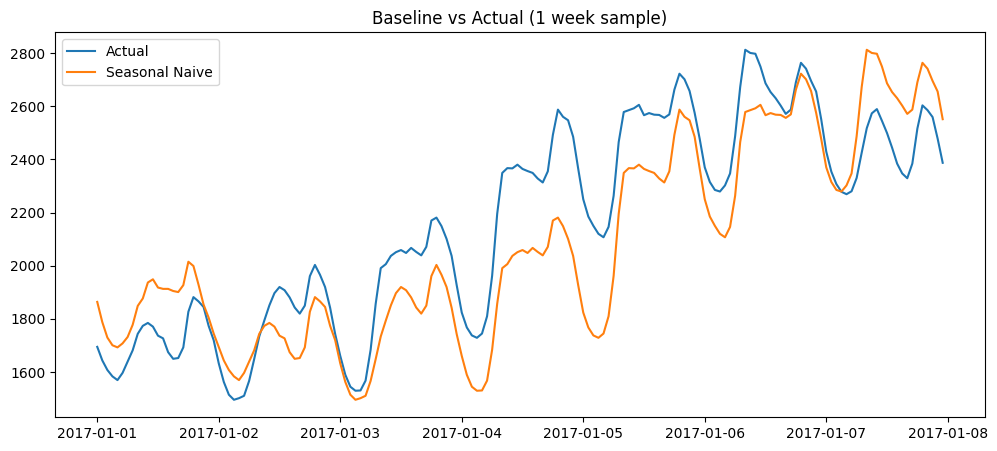

In [55]:
import matplotlib.pyplot as plt

sample = test.iloc[:168]

plt.figure(figsize=(12,5))
plt.plot(sample['DAYTON_MW'], label='Actual')
plt.plot(sample['baseline_pred'], label='Seasonal Naive')
plt.legend()
plt.title('Baseline vs Actual (1 week sample)')
plt.show()

## 3.4 Error in MAPE

In [56]:
df['DAYTON_MW'].describe()

count    121128.000000
mean       2038.032338
std         393.494300
min         982.000000
25%        1749.000000
50%        2009.000000
75%        2279.000000
max        3746.000000
Name: DAYTON_MW, dtype: float64

In [57]:
mape = np.mean(np.abs((test['DAYTON_MW'] - test['baseline_pred']) 
                       / test['DAYTON_MW'])) * 100

print("Baseline MAPE:", mape)

Baseline MAPE: 8.108361538507415


## 3.5 Error pattern analysis

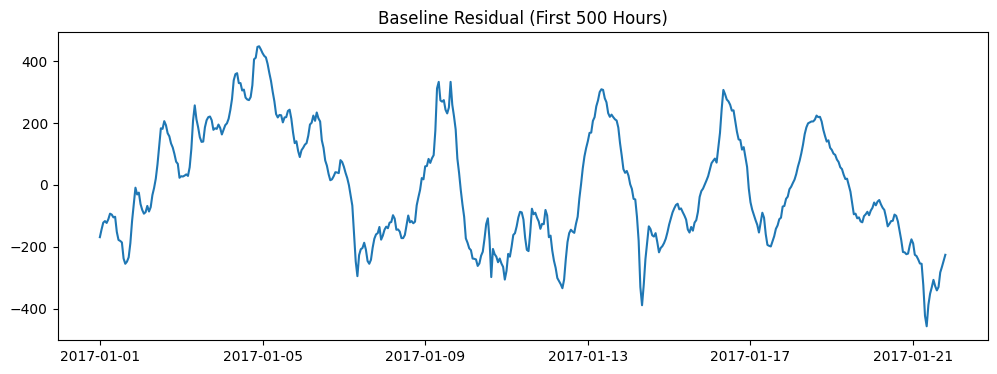

In [58]:
test['residual'] = test['DAYTON_MW'] - test['baseline_pred'] #residual

plt.figure(figsize=(12,4))
plt.plot(test['residual'][:500])
plt.title("Baseline Residual (First 500 Hours)")
plt.show()

# 4. Model XGBOOST

## 4.1 Define x and y

In [59]:
features = [
    'hour', 'dayofweek', 'month',
    'lag_1', 'lag_24', 'lag_168',
    'rolling_mean_24', 'rolling_std_24'
]

X_train = train[features]
y_train = train['DAYTON_MW']

X_test = test[features]
y_test = test['DAYTON_MW']

## 4.2 Train XGBoost and Predict

In [60]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [61]:
test['xgb_pred'] = model.predict(X_test)

## 4.3 Evaluate XGBoost performance

In [62]:
mae_xgb = mean_absolute_error(y_test, test['xgb_pred'])
rmse_xgb = np.sqrt(mean_squared_error(y_test, test['xgb_pred']))

mape_xgb = np.mean(np.abs((y_test - test['xgb_pred']) / y_test)) * 100

print("XGB MAE:", mae_xgb)
print("XGB RMSE:", rmse_xgb)
print("XGB MAPE:", mape_xgb)

XGB MAE: 20.907320401252857
XGB RMSE: 29.95733115827241
XGB MAPE: 1.033170338870713


Insight:
- This is over-optimistic evaluation because the MAPE drops significantly from 8% (BASELINE) to 1% (XGBoost)
- `lag_1` gives model actual access to previous hour's value into data test, allowing this model *one-step-ahead prediction with full ground truth availability*. In deployment, the ground truth is not always available

So, the next step we do *Walk-forward validation*

# 5. Walk-forward validation

## 5.1 making History variable

In [63]:
features = [
    'hour', 'dayofweek', 'month', 
    'lag_1', 'lag_24', 'lag_168',
    'rolling_mean_24', 'rolling_std_24'
]

history = train.copy()
predictions = []

## 5.2 Loop walk-forward

In [64]:
for timestamp in test.index:
    current_row = test.loc[[timestamp]].copy()

    # Update lag based on history (not actual test)
    current_row['lag_1'] = history['DAYTON_MW'].iloc[-1]
    current_row['lag_24'] = history['DAYTON_MW'].iloc[-24]
    current_row['lag_168'] = history['DAYTON_MW'].iloc[-168]

    current_row['rolling_mean_24'] = history['DAYTON_MW'].iloc[-24:].mean()
    current_row['rolling_std_24'] = history['DAYTON_MW'].iloc[-24:].std()

    #predict
    pred = model.predict(current_row[features])[0]

    predictions.append(pred)

    #add prediction to history
    new_row = pd.DataFrame(
        {'DAYTON_MW':pred},
        index=[timestamp]
    )

    history = pd.concat([history, new_row])

# 5.3 Walk-forward Evaluation

In [66]:
mae_walk = mean_absolute_error(test['DAYTON_MW'], predictions)
rmse_walk = np.sqrt(mean_squared_error(test['DAYTON_MW'],predictions))
mape_walk = np.mean(np.abs((test['DAYTON_MW'] - predictions)
                           / test['DAYTON_MW'])) *100

print("Walk-forward MAE:", mae_walk)
print("Walk-forward RMSE:", rmse_walk)
print("Walk-forward MAPE:", mape_walk)

Walk-forward MAE: 268.252159424443
Walk-forward RMSE: 362.66709364365323
Walk-forward MAPE: 12.319560322952892


Analysis:
- The increase in MAPE in this case is caused by the accumulation of errors that occurred in previous lags, resulting in the model being stable initially and then breakdown later.

Then we do *Direct Multi-Step Model*

# 6. Direct Multi-Step Model 

## 6.1 Multi-horizon target

In [68]:
HORIZON = 24

for i in range(1, HORIZON + 1):
    df[f'target_t+{i}'] = df['DAYTON_MW'].shift(-i)

df = df.dropna()

## 6.2 Features and Multi-output target

In [74]:
feature_cols = [
    'hour',
    'dayofweek',
    'month',
    'dayofyear',
    'lag_1',
    'lag_24',
    'lag_168',
    'rolling_mean_24',
    'rolling_std_24'
]

X = df[feature_cols]

target_cols = [f'target_t+{i}' for i in range(1, HORIZON+1)]
y = df[target_cols]

## 6.3 Train test split 

In [75]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 6.4 Train XGBoost Multi-Output

In [76]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

base_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...))

## 6.5 Evaluation

In [77]:
y_pred = model.predict(X_test)

mae_per_horizon = []

for i in range(HORIZON):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    mae_per_horizon.append(mae)

print("Average MAE:", np.mean(mae_per_horizon))

Average MAE: 88.22746023424475


In [78]:
for i, mae in enumerate(mae_per_horizon):
    print(f"Horizon t+{i+1} MAE: {mae}")

Horizon t+1 MAE: 35.52991599771974
Horizon t+2 MAE: 46.714952734149165
Horizon t+3 MAE: 56.33460090669973
Horizon t+4 MAE: 63.65110440564541
Horizon t+5 MAE: 69.64204239884658
Horizon t+6 MAE: 75.04704225689498
Horizon t+7 MAE: 79.6623593277769
Horizon t+8 MAE: 83.1945710650048
Horizon t+9 MAE: 86.20228598336004
Horizon t+10 MAE: 89.34434348472794
Horizon t+11 MAE: 91.83694398021163
Horizon t+12 MAE: 94.96244635076306
Horizon t+13 MAE: 97.16680288173045
Horizon t+14 MAE: 99.24983700266127
Horizon t+15 MAE: 101.07467043435254
Horizon t+16 MAE: 102.44697919630713
Horizon t+17 MAE: 103.27045001863921
Horizon t+18 MAE: 104.09537387390439
Horizon t+19 MAE: 104.8897342536959
Horizon t+20 MAE: 105.32647007922351
Horizon t+21 MAE: 105.47136527175827
Horizon t+22 MAE: 105.79911289523842
Horizon t+23 MAE: 106.72215072384832
Horizon t+24 MAE: 109.82349009871443


# 7. Freeze and Save Model 

In [79]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/forecast_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
